In [268]:
import random
import pygad
import networkx as nx
import matplotlib.pyplot as plt
import scipy as sp


In [269]:
def read_graph(file_path):
    graph = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()

    num_nodes = int(lines[0].strip())
    for node in range (1, num_nodes + 1):
        graph[node] = []

    for line in lines[1:]:
        parts = line.strip().split()
        if(len(parts) != 3):
            continue

        start = int(parts[0])
        finish = int(parts[1])
        distance = int(parts[2])

        graph[start].append((finish, distance))
    return graph

In [270]:
graph3 = read_graph("graph3.txt")
graph3

{1: [(2, 5), (3, 3), (4, 8)],
 2: [(5, 2), (6, 7)],
 3: [(6, 4), (7, 6)],
 4: [(7, 3), (8, 9)],
 5: [(9, 3), (10, 6)],
 6: [(10, 2), (11, 7)],
 7: [(11, 4), (12, 3)],
 8: [(12, 5)],
 9: [(13, 4)],
 10: [(13, 1), (14, 8)],
 11: [(14, 3), (15, 6)],
 12: [(15, 2)],
 13: [(16, 7)],
 14: [(16, 3)],
 15: [(16, 5)],
 16: [(17, 4)],
 17: [(18, 3)],
 18: [(19, 2)],
 19: [(20, 1)],
 20: []}

In [271]:
def graph_visualization(graph):
    G = nx.DiGraph()
    for node, value in graph.items():
        for nxt, distance in value:
            G.add_edge(node, nxt, weight=distance)

    pos = nx.spring_layout(G, k=5, iterations=100)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, width=1, arrowstyle='-|>', arrowsize=7)


    nx.draw_networkx_labels(G, pos, font_size=6, font_color='black')


    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5)

    plt.axis('off')
    plt.show()


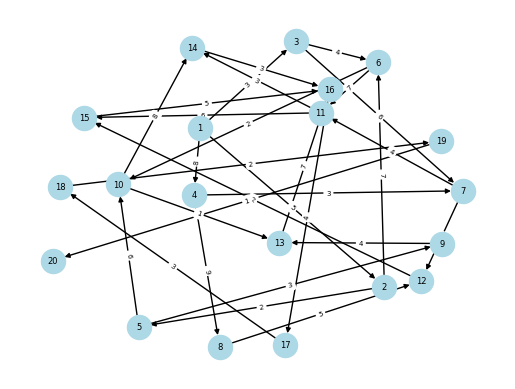

In [272]:
graph_visualization(graph3)

In [273]:
def path_distance(path, graph):
    result = 0

    for i in range(len(path) - 1):
        current_node = path[i]
        next_node = path[i+1]
        neighbors = graph[current_node]

        distance = None
        for(f, d) in neighbors:
            if f == next_node:
                distance = d
                break

        if distance is None:
            return None

        result += distance

    return result

In [274]:
path1 = [1, 3, 4, 5]
path2 = [1, 4, 5]

print("path1:", path_distance(path1, graph3))
print("path2:", path_distance(path2, graph3))

path1: None
path2: None


In [275]:
def generate_path(start, end, graph, max_steps = 100):
    current = start
    path = [current]

    for _ in range(max_steps):
        if current == end:
            return path

        neighbors = graph[current]
        if not neighbors:
            return None

        next_node, _ = random.choice(neighbors)
        path.append(next_node)
        current = next_node

    if current == end:
        return path
    else:
        return None

In [276]:
for i in range(10):
    p = generate_path(1, 20, graph3)
    print(p, " -> distance:", path_distance(p, graph3) if p is not None else None)

[1, 3, 7, 12, 15, 16, 17, 18, 19, 20]  -> distance: 29
[1, 2, 5, 9, 13, 16, 17, 18, 19, 20]  -> distance: 31
[1, 2, 5, 10, 14, 16, 17, 18, 19, 20]  -> distance: 34
[1, 3, 7, 11, 15, 16, 17, 18, 19, 20]  -> distance: 34
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20]  -> distance: 39
[1, 3, 7, 12, 15, 16, 17, 18, 19, 20]  -> distance: 29
[1, 4, 7, 11, 14, 16, 17, 18, 19, 20]  -> distance: 31
[1, 3, 7, 12, 15, 16, 17, 18, 19, 20]  -> distance: 29
[1, 2, 5, 9, 13, 16, 17, 18, 19, 20]  -> distance: 31
[1, 3, 6, 11, 15, 16, 17, 18, 19, 20]  -> distance: 35


In [277]:
def generate_initial_population(start, end , graph, population_size = 50):
    population = []
    attempts = 0

    while (len(population) < population_size and attempts < population_size * 10):
        path = generate_path(start, end, graph)

        if path is not None:
            population.append(path)

        attempts += 1
    return population

In [278]:
population = generate_initial_population(1, 20, graph3, population_size=15)
population

[[1, 2, 5, 10, 13, 16, 17, 18, 19, 20],
 [1, 4, 7, 12, 15, 16, 17, 18, 19, 20],
 [1, 3, 6, 10, 14, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 15, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 15, 16, 17, 18, 19, 20],
 [1, 2, 6, 10, 14, 16, 17, 18, 19, 20],
 [1, 4, 7, 12, 15, 16, 17, 18, 19, 20],
 [1, 3, 7, 12, 15, 16, 17, 18, 19, 20],
 [1, 3, 7, 11, 14, 16, 17, 18, 19, 20],
 [1, 4, 8, 12, 15, 16, 17, 18, 19, 20],
 [1, 4, 8, 12, 15, 16, 17, 18, 19, 20],
 [1, 2, 6, 10, 14, 16, 17, 18, 19, 20],
 [1, 3, 6, 10, 13, 16, 17, 18, 19, 20],
 [1, 2, 5, 10, 14, 16, 17, 18, 19, 20],
 [1, 4, 7, 11, 15, 16, 17, 18, 19, 20]]

In [279]:
def fitness(path, graph, start, end):
    if path is None:
        return 1e9

    if path[0] != start or path[-1] != end:
        return 1e9

    dist = path_distance(path, graph)

    if dist is None:
        return 1e9

    return dist

In [280]:
start = 1
end = 20

pop = generate_initial_population(start, end, graph3, population_size=5)

for p in pop:
    print(p, "fitness:", fitness(p, graph3, start, end))


[1, 2, 5, 9, 13, 16, 17, 18, 19, 20] fitness: 31
[1, 3, 6, 11, 15, 16, 17, 18, 19, 20] fitness: 35
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20] fitness: 39
[1, 4, 7, 12, 15, 16, 17, 18, 19, 20] fitness: 31
[1, 3, 6, 11, 15, 16, 17, 18, 19, 20] fitness: 35


In [281]:
def tournament_selection(population, fitnesses, tournament_size = 3):
    indices = random.sample(range(len(population)), tournament_size)
    best_idx = min(indices, key=lambda i: fitnesses[i])

    return population[best_idx]

In [282]:
start = 1
end = 20
population = generate_initial_population(start, end, graph, population_size=10)
fitnesses = [fitness(p, graph, start, end) for p in population]

print("POPULACIJA:")
for p, f in zip(population, fitnesses):
    print(p, "fitness:", f)

print("\nIZBRAN STARŠ:")
parent = tournament_selection(population, fitnesses, tournament_size=3)
print(parent, "fitness:", fitness(parent, graph, start, end))


NameError: name 'graph' is not defined

In [ ]:
def mutate(path, graph, mutation_probability = 0.1):
    new_path = path[:]

    for i in range(len(new_path) - 1):
        if random.random() < mutation_probability:
            current = new_path[i]
            neighbors = graph[current]

            if not neighbors:
                continue

            next_node, _ = random.choice(neighbors)
            new_path[i + 1] = next_node

    return new_path

In [ ]:
p = population[0]
print("Original:", p)

mutated = mutate(p, graph, mutation_probability=0.5)
print("Mutated: ", mutated)

print("Fitness original:", fitness(p, graph, start, end))
print("Fitness mutated: ", fitness(mutated, graph, start, end))


Original: [1, 3, 7, 11, 15, 16, 17, 18, 19, 20]
Mutated:  [1, 3, 6, 10, 15, 16, 17, 18, 19, 20]
Fitness original: 34
Fitness mutated:  1000000000.0


In [ ]:
def single_point_crossover(parent1, parent2):
    if len(parent1) < 3 or len(parent2) < 3:
        return parent1[:], parent2[:]

    cut1 = random.randint(1, len(parent1) - 2)
    cut2 = random.randint(1, len(parent2) - 2)

    child1 = parent1[:cut1] + parent2[cut2:]
    child2 = parent2[:cut2] + parent1[cut1:]

    return child1, child2

In [ ]:
start = 1
end = 20

population = generate_initial_population(start, end, graph, population_size=4)
fitnesses = [fitness(p, graph, start, end) for p in population]

print("STARŠI:")
for p, f in zip(population, fitnesses):
    print(p, "fitness:", f)

# izberemo 2 starša
parent1 = tournament_selection(population, fitnesses, tournament_size=3)
parent2 = tournament_selection(population, fitnesses, tournament_size=3)

print("\nIZBRAN STARŠ 1:", parent1)
print("IZBRAN STARŠ 2:", parent2)

child1, child2 = single_point_crossover(parent1, parent2)

print("\nOTROCI:")
print("child1:", child1, "fitness:", fitness(child1, graph, start, end))
print("child2:", child2, "fitness:", fitness(child2, graph, start, end))


STARŠI:
[1, 2, 6, 11, 14, 16, 17, 18, 19, 20] fitness: 35
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20] fitness: 39
[1, 4, 7, 11, 14, 16, 17, 18, 19, 20] fitness: 31
[1, 2, 6, 11, 15, 16, 17, 18, 19, 20] fitness: 40

IZBRAN STARŠ 1: [1, 4, 7, 11, 14, 16, 17, 18, 19, 20]
IZBRAN STARŠ 2: [1, 4, 7, 11, 14, 16, 17, 18, 19, 20]

OTROCI:
child1: [1, 4, 7, 4, 7, 11, 14, 16, 17, 18, 19, 20] fitness: 1000000000.0
child2: [1, 11, 14, 16, 17, 18, 19, 20] fitness: 1000000000.0


In [ ]:
def genetic_algorithm(start, end, graph, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3):
    population = generate_initial_population(start, end, graph, population_size)
    best_path = None
    best_fitness = float("inf")

    for gen in range(generations):
        fitnesses = [fitness(p, graph, start, end) for p in population]

        gen_best_idx = min(range(len(population)), key=lambda i: fitnesses[i])
        gen_best_path = population[gen_best_idx]
        gen_best_fitness = fitnesses[gen_best_idx]

        if gen_best_fitness < best_fitness:
            best_fitness = gen_best_fitness
            best_path = gen_best_path

        new_population = []
        new_population.append(best_path)

        while len(new_population) < population_size:
            # izberi starše
            parent1 = tournament_selection(population, fitnesses, tournament_size)
            parent2 = tournament_selection(population, fitnesses, tournament_size)

            # crossover
            child1, child2 = single_point_crossover(parent1, parent2)

            # mutacija
            child1 = mutate(child1, graph, mutation_probability)
            child2 = mutate(child2, graph, mutation_probability)
            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_path, best_fitness


In [ ]:
start = 1
end = 20

best_path, best_fit = genetic_algorithm(start, end, graph, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3)

print("Najdena pot:", best_path)
print("Dolžina poti:", best_fit)


Najdena pot: [1, 3, 6, 10, 13, 16, 17, 18, 19, 20]
Dolžina poti: 27


In [ ]:
def generate_path2(targets, graph):
    

   
    current = targets[0]
    path = [current]

        
    success = True
    
    
    for i in range(len(targets)-1):
        current = targets[i]
        nxt = targets[i+1]
        segment = [current]

        future_targets = set(targets[i+2:])
         

    
        while (segment[-1]!= nxt):
            
            possible_nodes =  [node for node, _ in graph.get(segment[-1], []) if node not in segment and node not in future_targets]

            
           
                
            if not possible_nodes:
                success = False
                break
   
            n = random.choice(possible_nodes)
            segment.append(n)

        if not success:
            break


        path.extend(segment[1:])

    if success:
        return path 
    
    return []  

 

In [ ]:
for i in range(10):
    p = generate_path2([1, 14, 20], graph3)
    print(p, " -> distance:", path_distance(p, graph3))

[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[1, 2, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 35
[1, 3, 6, 11, 14, 16, 17, 18, 19, 20]  -> distance: 30
[]  -> distance: 0
[]  -> distance: 0
[1, 3, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 30
[]  -> distance: 0


In [ ]:
def generate_initial_population2(targets, graph, population_size = 50):
    population = []
    attempts = 0

    while (len(population) < population_size and attempts < population_size * 10):
        path = generate_path2(targets, graph)

        if path :
            population.append(path)

        attempts += 1
    return population

In [ ]:
population2 = generate_initial_population2([1, 3, 19], graph3, population_size=15)
population2

[[1, 3, 7, 11, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 6, 11, 14, 16, 17, 18, 19],
 [1, 3, 7, 11, 14, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 6, 10, 14, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 6, 10, 14, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 6, 11, 15, 16, 17, 18, 19]]

In [ ]:
def make_fitness2(path, graph, targets):
    def fitness2(ga_instance, solution, solution_idx):



        if path is None:
            return 1e-9
    
        it = iter(path)
        if not (all(target in it for target in targets)):
            return 1e-9

        dist = path_distance(path, graph)

        if dist is None:
            return 1e-9

        return 1.0/ (1.0+dist)
    
    return fitness2

In [ ]:


for p in population2:
    print(p, "fitness:", make_fitness2(p, graph3, [1, 3, 19]))


[1, 3, 7, 11, 15, 16, 17, 18, 19] fitness: 33
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 6, 11, 14, 16, 17, 18, 19] fitness: 29
[1, 3, 7, 11, 14, 16, 17, 18, 19] fitness: 28
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 6, 10, 14, 16, 17, 18, 19] fitness: 29
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 6, 10, 14, 16, 17, 18, 19] fitness: 29
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: 28
[1, 3, 6, 11, 15, 16, 17, 18, 19] fitness: 34


In [ ]:
def mutate2(path, graph, targets, mutation_probability = 0.1):
    new_path = path[:]

    for i in range(len(new_path) - 1):
        if path[i+1] in targets:
            continue
        if random.random() < mutation_probability:
            current = new_path[i]
            neighbors = [n for n, _ in graph[current] if n not in targets]


            if not neighbors:
                continue
          
            next_node = random.choice(neighbors)
            new_path[i + 1] = next_node

    return new_path

In [ ]:
p2 = population2[0]
print("Original:", p2)

mutated2 = mutate2(p2, graph3,[1, 3, 19], mutation_probability=0.5)
print("Mutated: ", mutated2)

print("Fitness original:", fitness2(p2, graph3, [1, 3, 19]))
print("Fitness mutated: ", fitness2(mutated2, graph3, [1, 3, 19]))


Original: [1, 3, 6, 11, 15, 16, 17, 18, 19]
Mutated:  [1, 3, 6, 10, 15, 16, 17, 18, 19]
Fitness original: 34
Fitness mutated:  1000000000.0
